# AUPRC Results of Fine Tuning

In [42]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))
sys.path

['/home/sanjanag05/.conda/envs/haven/lib/python311.zip',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11/lib-dynload',
 '',
 '/home/sanjanag05/.conda/envs/haven/lib/python3.11/site-packages',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../..',
 '/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../..']

In [43]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import mannwhitneyu, wilcoxon, ranksums, iqr

from src.utils import utils, evaluation_utils, visualization_utils

In [44]:
output_filepaths = {
"original": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/mlm_1e-5_final.csv"),
"epoch50": os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/epochs40_60_patience_30.csv"),
"epoch100":  os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/raw/uniref50_coronaviridae/uniref50_corona_top_hosts/epoch2030_patience30_hybrid_attention_msl256s64ae_bn_cls_fnn_2l_d1024_lr3e-4_output.csv")
}

In [45]:
def classwise_auprc_analysis(output_filepaths, figure_output_filepath=None):
    itr_col = "itr"
    experiment_col = "experiment"
    y_true_col = "y_true"
    auprc_results = []
    for model, output_filepath in output_filepaths.items():
        df = pd.read_csv(output_filepath, index_col=0)
        print(f"Read output {model} = {df.shape}")
        
        cols = df.columns
        classes = list(set(cols) - set([itr_col, experiment_col, y_true_col]))
        itrs = df[itr_col].unique()
    
        for itr in itrs:
            df_itr = df[df[itr_col] == itr]
            _, auprcs_df = evaluation_utils.compute_class_auprc(df_itr, y_pred_columns=classes, y_true_col=y_true_col)
            auprcs_df["model"] = model
            auprcs_df["itr"] = itr
            auprc_results.append(auprcs_df)
    metadata = utils.compute_class_distribution(df_itr, y_true_col, format=False)
    metadata_formatted = utils.compute_class_distribution(df_itr, y_true_col, format=True)
    metadata_sorted = {}
    for k, v in metadata.items():
        metadata_sorted[metadata_formatted[k]] = v
    
    auprc_results_df = pd.concat(auprc_results, ignore_index=True)
    auprc_results_df.replace({"class":metadata_formatted}, inplace=True)
    sns.set_context("paper")
    sns.axes_style("whitegrid")
    
    FIGURE_CONFIG = {
        "figsize": (12, 6),
        "xtick.labelsize": 14,
        "ytick.labelsize": 14    
    }
    
    color_palette = sns.cubehelix_palette(start=3, rot=4.5, hue=1, gamma=0.9, dark=0.7, light=0.4, reverse=True, n_colors=auprc_results_df["model"].nunique())
    
    visualization_utils.pre_plot_config(FIGURE_CONFIG)
    ax = sns.boxplot(data=auprc_results_df, x="class", y="auprc", hue="model", 
                     order=metadata_sorted, linewidth=1.5, fliersize=5, linecolor="black",
                     palette=color_palette)
    
    bg_colors = [ "gray", "white",]
    
    plt.draw()
    
    ax.set_ylim(0, 1)
    ax.set_ylabel("AUPRC", size=14)
    ax.set_xlabel("", size=0, labelpad=0)
    sns.move_legend(ax, "lower center", bbox_to_anchor=(.5, 1), ncol=5, title=None, frameon=False)
    plt.setp(ax.get_legend().get_texts(), fontsize=14)
    visualization_utils.wrap_ticklabels(ax, axis="x")
    
    n_classes = auprc_results_df["class"].nunique()
    for i in range(n_classes):
        ax.axvspan(i - .5, i + .5, color=bg_colors[i%2], alpha=0.2)
    
    if figure_output_filepath:
        visualization_utils.view(figure_output_filepath)
    plt.show()

Read output original = (135, 8)
Read output epoch50 = (135, 8)
Read output epoch100 = (135, 8)


/home/sanjanag05/HAVEN/src/jupyter_notebooks/datasets/generation/../../../../src/utils/visualization_utils.py:119: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(wrapped_labels, rotation=0)


<Figure size 640x480 with 0 Axes>

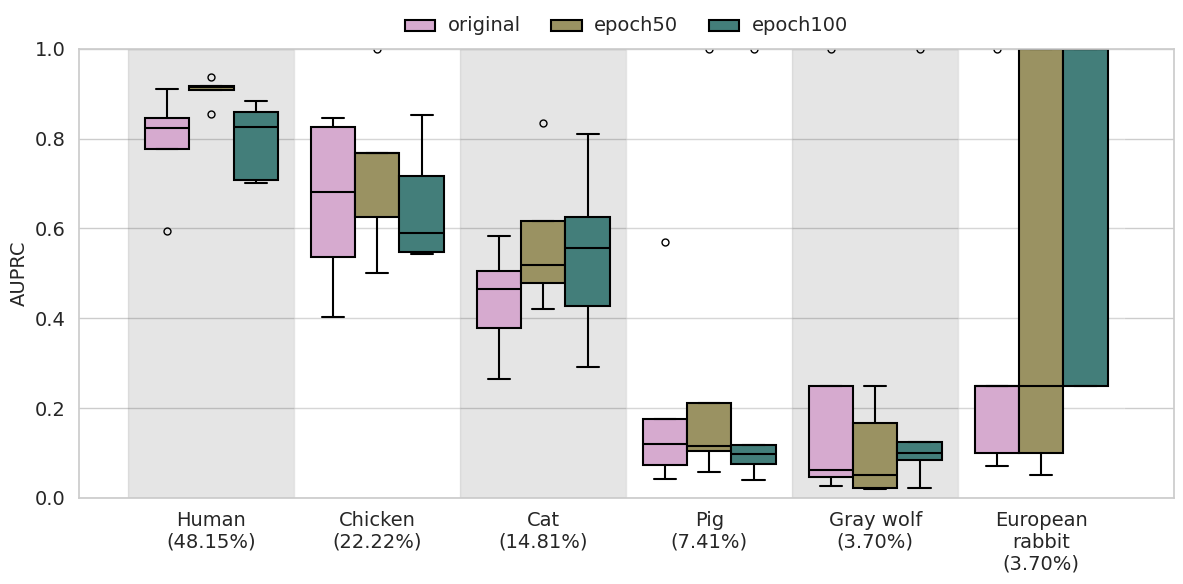

In [46]:

figure_output_filepath = os.path.join(os.getcwd(), "..","..", "..", "..", "/home/sanjanag05/HAVEN/output/visualization/uniref50/host_multi_all_models_classwise_aurpc_boxplot.pdf")
classwise_auprc_analysis(output_filepaths, figure_output_filepath)

# Analysis

For human, pig, and gray wolf, <b> epoch50 </b> is better

For european rabbit, <b> both </b> are tied

For cat, <b> epoch100 </b> seems to be better

For chicken, <b> epoch50 has better median </b>, but <b> epoch100 </b> has better peak performance

I think that Epoch50 is the best one because it is better on average. Even though epoch100 usually has better peak performance, epoch50 will be better consistently